# **Capstone Backtester**
_Welcome to the Capstone Backtester: a modular, extensible backtesting tool designed to evaluate trading strategies on historical stock data._

_This tool enables dynamic selection and testing of multiple technical strategies, including **SMA Crossover**, **EWMA Crossover**, **MACD**, **RSI + Bollinger Bands**, and **ATR Breakout**._  
_It provides clear performance visualizations using Seaborn and Matplotlib, comparing strategy returns against buy-and-hold baselines._

_The project is designed for easy expansion; new strategies can be added seamlessly by integrating callable signal generation modules._


### **Import Libraries + Scripts**

In [77]:
# Import libraries + Scripts
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from strategies import sma_crossover_strategy, ewma_crossover_strategy, macd_strategy, rsi_bollinger_strategy, atr_breakout_strategy


### **Set Parameters**

In [78]:
# Set Backtest Settings
ticker = 'QQQ'  # Example: 'TSLA', 'AAPL', etc.
start_date = '2019-10-10' # Pull from 50 days earlier to allow indicators to warm up
end_date = '2020-12-30'

# Select strategy
strategy_choice = 'MACD'  # Options: 'SMA', 'EWMA', 'MACD', 'RSI', 'ATR'

### **Download Data**

In [79]:
# Download data
df = yf.download(ticker, start=start_date, end=end_date, group_by="ticker")  # This automatically groups by ticker

# Check if it's MultiIndex and flatten
if isinstance(df.columns, pd.MultiIndex):
    df = df[ticker]  # Select only TSLA's data

# Keep only needed columns
df = df[['High', 'Low', 'Close']].dropna()

[*********************100%***********************]  1 of 1 completed


### **Apply Strategy**
**Note**: Early data points are excluded from the graphs and backtest results to allow technical indicators (e.g., moving averages, RSI) to "warm up" and generate reliable signals.

In [80]:
# Apply Strategy based on strategy_choice

if strategy_choice == 'SMA':
    df, warmup_window = sma_crossover_strategy.generate_signals(df, short_window=20, long_window=50)

elif strategy_choice == 'EWMA':
    df, warmup_window = ewma_crossover_strategy.generate_signals(df, short_window=12, long_window=26)

elif strategy_choice == 'MACD':
    df, warmup_window = macd_strategy.generate_signals(df, short_window=12, long_window=26, signal_window=9)

elif strategy_choice == 'RSI':
    df, warmup_window = rsi_bollinger_strategy.generate_signals(df, rsi_window=14, bollinger_window=20)

elif strategy_choice == 'ATR':
    df, warmup_window = atr_breakout_strategy.generate_signals(df, scale_factor=0.5, atr_window=14, breakout_window=20)

else:
    raise ValueError(f"Strategy '{strategy_choice}' not recognized. Choose 'SMA', 'EWMA', 'RSI', or 'ATR'.")

# Remove warmup period to let the indicators start at t=0
df = df.iloc[warmup_window:].copy()

c:\Users\tobys\Downloads\strategies\macd_strategy.py:37: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df['Position'] = df['Signal'].replace(to_replace=0, method='ffill')


### **Calculate Strategy Performance**

In [81]:
# Calculate daily returns
df['Market_Returns'] = df['Close'].pct_change()

# Calculate strategy returns
# If in a "Position" (1 or -1), capture daily returns; else, zero
df['Strategy_Returns'] = df['Market_Returns'] * df['Position'].shift(1)

# Calculate cumulative returns
df['Cumulative_Market'] = (1 + df['Market_Returns']).cumprod()
df['Cumulative_Strategy'] = (1 + df['Strategy_Returns']).cumprod()

# Calculate cumulative returns in percentage
df['Cumulative_Market_Percent'] = (df['Cumulative_Market'] - 1.0) * 100
df['Cumulative_Strategy_Percent'] = (df['Cumulative_Strategy'] - 1.0) * 100

# Calculate outperformance
df['Outperformance'] = df['Cumulative_Strategy'] - df['Cumulative_Market']
df['Daily_Outperformance'] = df['Strategy_Returns'] - df['Market_Returns']

# Drop any NaNs created by shifting
df = df.dropna()

### **Plot Trading Signals + Strategy Overlay**

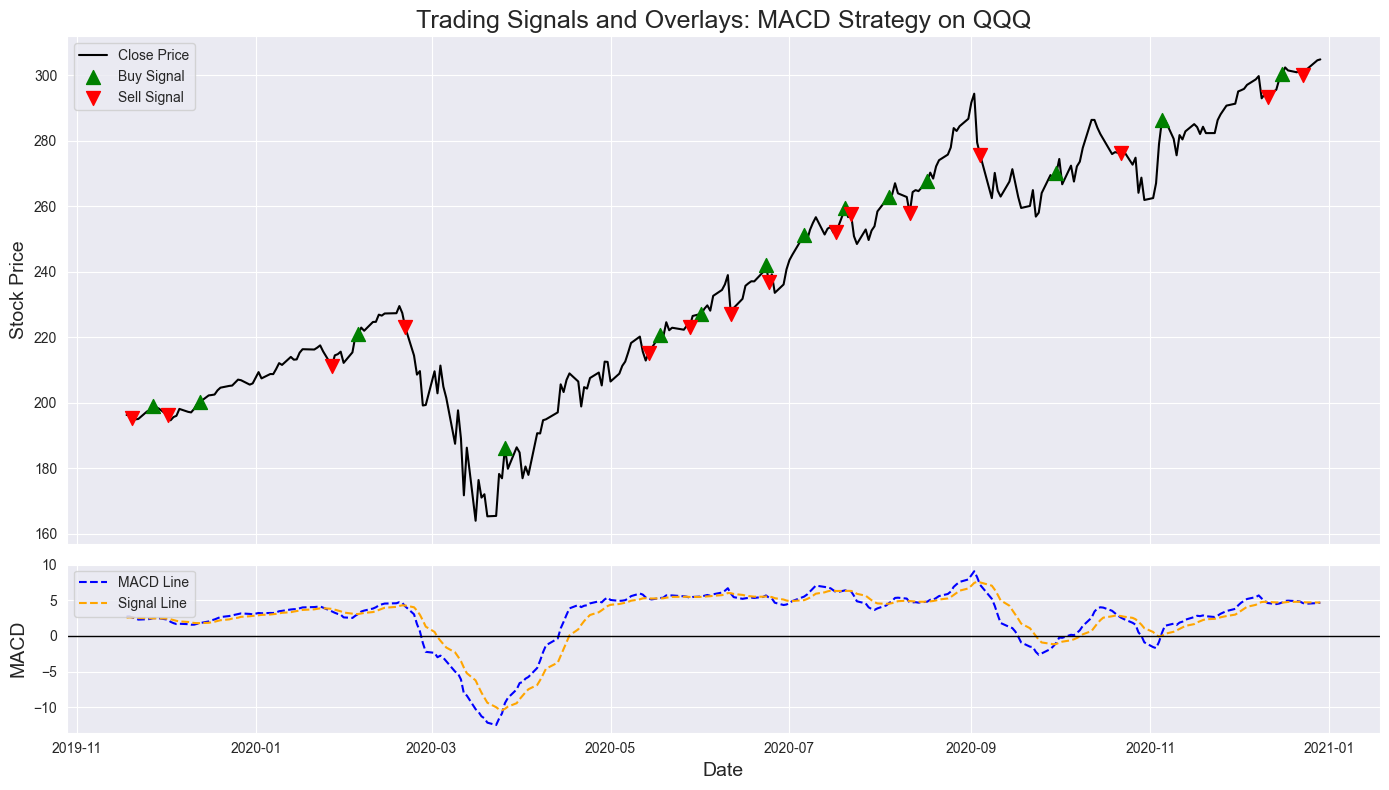

In [82]:
sns.set_style('darkgrid')

# --- For MACD Strategy (Separate Subplots) ---
if strategy_choice == 'MACD':
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Top Plot - Close Price and Buy/Sell Signals
    sns.lineplot(ax=ax1, data=df, x=df.index, y='Close', label='Close Price', color='black')

    # Plot Buy signals
    buy_signals = df[df['Signal'] == 1]
    ax1.scatter(buy_signals.index, buy_signals['Close'], label='Buy Signal', marker='^', color='green', s=100, zorder=5)

    # Plot Sell signals
    sell_signals = df[df['Signal'] == -1]
    ax1.scatter(sell_signals.index, sell_signals['Close'], label='Sell Signal', marker='v', color='red', s=100, zorder=5)

    # Title and legend
    ax1.set_title(f"Trading Signals and Overlays: {strategy_choice} Strategy on {ticker}", fontsize=18)
    ax1.set_ylabel("Stock Price", fontsize=14)
    ax1.legend()

    # Bottom Plot - MACD and Signal Line
    sns.lineplot(ax=ax2, data=df, x=df.index, y='MACD', label='MACD Line', color='blue', linestyle='--')
    sns.lineplot(ax=ax2, data=df, x=df.index, y='Signal_Line', label='Signal Line', color='orange', linestyle='--')
    ax2.axhline(0, color='black', linewidth=1)

    ax2.set_ylabel("MACD", fontsize=14)
    ax2.set_xlabel("Date", fontsize=14)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# --- For All Other Strategies ---
else:
    plt.figure(figsize=(14,7))

    # Plot Close Price
    sns.lineplot(data=df, x=df.index, y='Close', label='Close Price', color='black')

    # Plot Buy signals
    buy_signals = df[df['Signal'] == 1]
    plt.scatter(buy_signals.index, buy_signals['Close'], label='Buy Signal', marker='^', color='green', s=100, zorder=5)

    # Plot Sell signals
    sell_signals = df[df['Signal'] == -1]
    plt.scatter(sell_signals.index, sell_signals['Close'], label='Sell Signal', marker='v', color='red', s=100, zorder=5)

    # Strategy-specific overlays
    if strategy_choice == 'SMA':
        sns.lineplot(data=df, x=df.index, y='SMA_Short', label='SMA Short', color='blue', linestyle='--')
        sns.lineplot(data=df, x=df.index, y='SMA_Long', label='SMA Long', color='orange', linestyle='--')

    elif strategy_choice == 'EWMA':
        sns.lineplot(data=df, x=df.index, y='EWMA_Short', label='EWMA Short', color='blue', linestyle='--')
        sns.lineplot(data=df, x=df.index, y='EWMA_Long', label='EWMA Long', color='orange', linestyle='--')

    elif strategy_choice == 'RSI':
        sns.lineplot(data=df, x=df.index, y='Upper_Band', label='Upper Band', color='purple', linestyle='--')
        sns.lineplot(data=df, x=df.index, y='Lower_Band', label='Lower Band', color='brown', linestyle='--')

    elif strategy_choice == 'ATR':
        sns.lineplot(data=df, x=df.index, y='Upper_Breakout', label='Upper Breakout', color='purple', linestyle='--')
        sns.lineplot(data=df, x=df.index, y='Lower_Breakout', label='Lower Breakout', color='brown', linestyle='--')

    plt.title(f"Trading Signals and Overlays: {strategy_choice} Strategy on {ticker}", fontsize=18)
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Stock Price", fontsize=14)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

### **Plot Cumulative Returns + Outperformance**

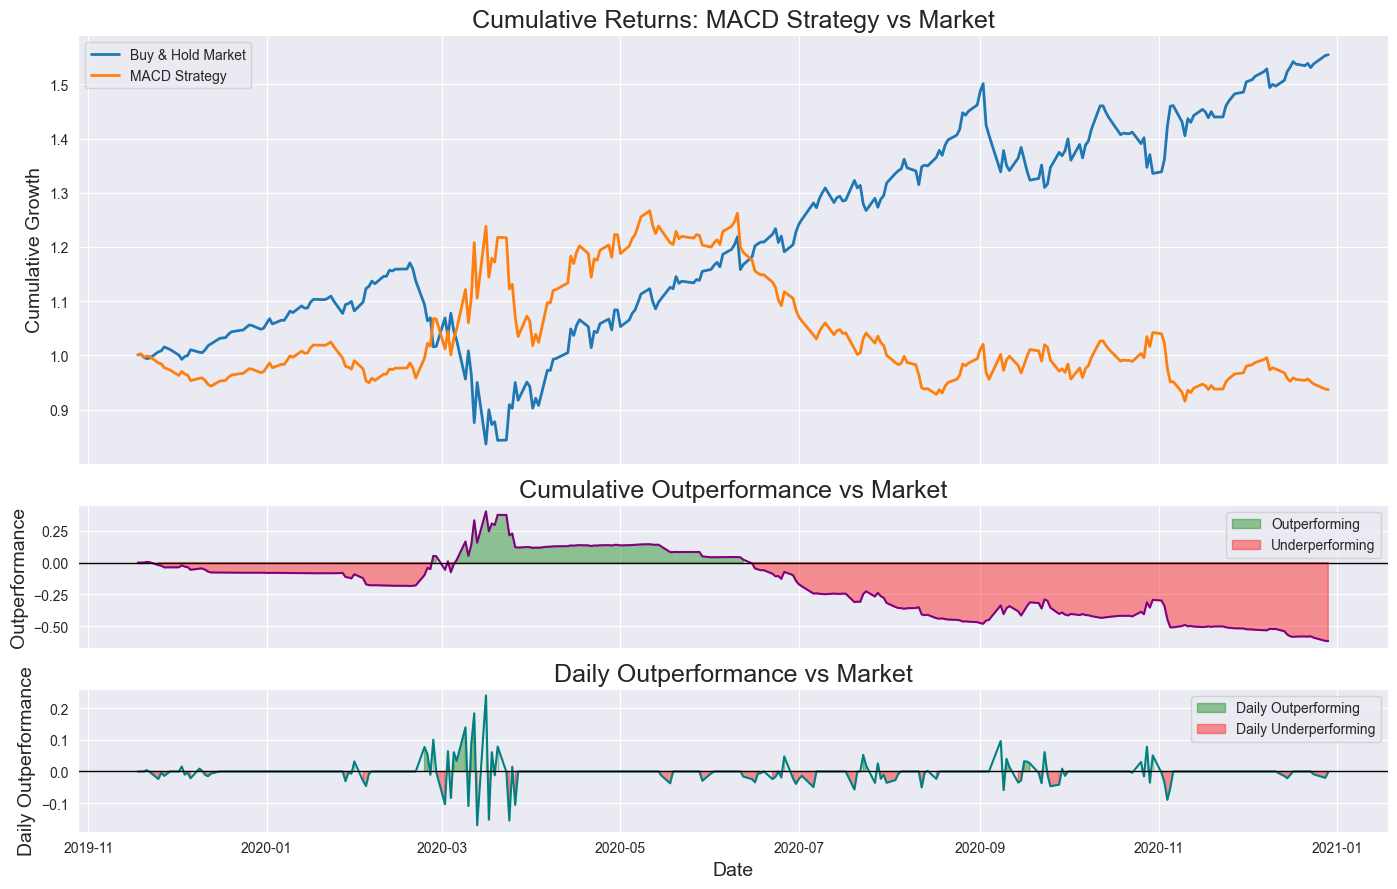

In [83]:
# Set Style
sns.set_style('darkgrid')

# Setup subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14,9), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})

# Cumulative Returns
sns.lineplot(ax=ax1, data=df, x=df.index, y='Cumulative_Market', label='Buy & Hold Market', linewidth=2)
sns.lineplot(ax=ax1, data=df, x=df.index, y='Cumulative_Strategy', label=f'{strategy_choice} Strategy', linewidth=2)

ax1.set_title(f"Cumulative Returns: {strategy_choice} Strategy vs Market", fontsize=18)
ax1.set_ylabel("Cumulative Growth", fontsize=14)
ax1.legend()

# Outperformance
sns.lineplot(ax=ax2, data=df, x=df.index, y='Outperformance', color='purple')
ax2.fill_between(df.index, df['Outperformance'], 0, 
                 where=(df['Outperformance'] > 0), color='green', alpha=0.4, label='Outperforming')
ax2.fill_between(df.index, df['Outperformance'], 0, 
                 where=(df['Outperformance'] <= 0), color='red', alpha=0.4, label='Underperforming')

ax2.axhline(0, color='black', linewidth=1)
ax2.set_title(f"Cumulative Outperformance vs Market", fontsize=18)
ax2.set_xlabel("Date", fontsize=14)
ax2.set_ylabel("Outperformance", fontsize=14)
ax2.legend()

# Daily outperformance
sns.lineplot(ax=ax3, data=df, x=df.index, y='Daily_Outperformance', color='teal')
ax3.fill_between(df.index, df['Daily_Outperformance'], 0,
                 where=(df['Daily_Outperformance'] > 0), color='green', alpha=0.4, label='Daily Outperforming')
ax3.fill_between(df.index, df['Daily_Outperformance'], 0,
                 where=(df['Daily_Outperformance'] <= 0), color='red', alpha=0.4, label='Daily Underperforming')
ax3.axhline(0, color='black', linewidth=1)
ax3.set_title(f"Daily Outperformance vs Market", fontsize=18)
ax3.set_ylabel("Daily Outperformance", fontsize=14)
ax3.set_xlabel("Date", fontsize=14)
ax3.legend()

plt.tight_layout()
plt.show()


### **Calculate Performance Metrics**

In [84]:
# Final Cumulative Returns
final_strategy_return = (df['Cumulative_Strategy'].iloc[-1] - 1) * 100
final_market_return = (df['Cumulative_Market'].iloc[-1] - 1) * 100

# Volatility (annualized)
strategy_volatility = np.std(df['Strategy_Returns']) * np.sqrt(252) * 100
market_volatility = np.std(df['Market_Returns']) * np.sqrt(252) * 100

# Sharpe Ratio (assuming risk-free rate = 0 for simplicity)
strategy_sharpe = (np.mean(df['Strategy_Returns']) / np.std(df['Strategy_Returns'])) * np.sqrt(252)
market_sharpe = (np.mean(df['Market_Returns']) / np.std(df['Market_Returns'])) * np.sqrt(252)

# Create Performance Metrics Table

metrics = {
    'Metric': [
        'Final Strategy Return (%)',
        'Final Market Return (%)',
        'Strategy Volatility (%)',
        'Market Volatility (%)',
        'Strategy Sharpe Ratio',
        'Market Sharpe Ratio'
    ],
    'Value': [
        round(final_strategy_return, 2),
        round(final_market_return, 2),
        round(strategy_volatility, 2),
        round(market_volatility, 2),
        round(strategy_sharpe, 2),
        round(market_sharpe, 2)
    ]
}

# Turn into DataFrame
metrics_df = pd.DataFrame(metrics)

# Display
metrics_df

,Metric,Value
0,Final Strategy Return (%),-6.32
1,Final Market Return (%),55.45
2,Strategy Volatility (%),33.98
3,Market Volatility (%),33.86
4,Strategy Sharpe Ratio,-0.00
5,Market Sharpe Ratio,1.34


### **Summary**

_Through this project, we developed a modular, extensible backtesting tool capable of dynamically testing multiple trading strategies against historical stock data. 
The tool provides clear visualizations of trading signals, cumulative performance, and outperformance relative to a buy-and-hold baseline. 
Results show that technical strategies like SMA crossovers and RSI+Bollinger bands can outperform the market during very brief periods of volatility but typically underperform during strong bull trends. 
Future improvements could include adding transaction cost modeling, parameter optimization, and the integration of machine learning-based strategies._